### Neuronalen Netze und simultane Hyperparameteroptimierung 

Dieses Notebook dient dem Anknüpfen der Erkenntnisse aus 05_flo_NN, 05_Neural_Network_Felix, 05_Neural_Network_Koja und einer Simultan-Optimierung der Hyperparameter sowie weiterem Featureengeneering.
Als nächster logischer Schritt bietet sich aufbauend auf den Erkenntnissen von Felix H. die Analyse durch Bayesianische Optimierung.


### Bayesianische Optimierung 
Die Idee: 
Beim Training eines neuronalen Netzes sind zuvor Auswirkungen der Änderungen der Kernrate und Neuronenanzahl auf den Loss unbekannt -> Blackbox. Die Optimierung über den [keras_tuner] nutzt ein statistisches Modell (Gauß-Prozess) un schätzt für jede Hyperparameterkombination die erwartete Treffergenauigkeit und die Unsicherheit des Modells. Die Akquisitionsfunktion entscheidet über den als nächstes getesteten Punkt und wägt dabei zwischen Nähe zu vielverprechenden Werten und der Erkundung neuer Bereiche mit hoher Unsicherheit ab.  
Der Keras BayesianOptimization-Tuner testet zunächst zufällige Hyperparameterkombinationen. Dann berechnet er vielverprechende Kombinationen aus den bisherigen Ergebnissen. Mit diesen Prametern wird ein Netz trainiert und das Ergebnis den vorigen Ergebnissen hinzugefügt. Anschlißend beginnt die Berechnung der vielverprechenden Kombinationen erneut bis max-trials erreicht ist.   
Der Geschwindigkeitszuwachs erfolgt dabei durch die Möglichkeit des Abbruchs nach weniger als der maximalen Epochenanzahl, sofern ein Netz als nicht vielversprechend interpretiert wird.

Zunächst erfolgt eine Aufteilung der Daten. Der Einfach- und Vergleichbarkeit wegen wird der gleiche Code wie in 05_Neural_Network_Felix.ipynb verwendet.

In [5]:
###Code übernommen aus 05_Neural_Network_Felix.ipynb
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LinearRegression

from utils.data import load_and_clean_data, get_train_test_split
from utils.evaluation import evaluate_predictions, add_result, evaluate_test_predictions
from utils.plotting import plot_features_vs_target, plot_predicted_vs_actual, plot_residuals, save_fig

plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"python Version: {sys.version}")



TensorFlow Version: 2.21.0
Numpy Version: 2.2.6
Pandas Version: 2.3.3
Matplotlib Version: 3.10.8
python Version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


In [ ]:
###Code übernommen aus 05_Neural_Network_Felix.ipynb
def build_model(hidden_layers, activation='relu', learning_rate=0.001):
    """Erstelle ein Sequential-Modell mit gegebener Architektur."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))  # Regression Output
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    return model


def train_and_evaluate(model, name, x_train, y_train, x_val, y_val, x_test, y_test,
                       epochs=100, batch_size=32, verbose=0):

    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )

    y_train_pred = model.predict(x_train, verbose=0).flatten()
    y_test_pred = model.predict(x_test, verbose=0).flatten()

    result = evaluate_predictions(y_train, y_train_pred, y_test, y_test_pred, name)
    add_result(result)

    return history, result

### Daten laden und transformieren + skalieren
Die Daten werden in Trainings und Testdaten gesplitet. Ein Teil Trainingsdatensatzes wird als Validierungsdatensatz verwendet. Der aufgeteilte Datensatz erhält dann folgende Umfänge und Features:

In [118]:
###Code übernommen aus 05_Neural_Network_Felix.ipynb
df = load_and_clean_data()
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")
###Code übernommen aus 05_Neural_Network_Felix.ipynb
X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")
###Code übernommen aus 05_Neural_Network_Felix.ipynb
X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Neuronale Netze trainieren


Die bisherige Analyse ergab eine optimale Lernrate zwischen .001 und 0.01. Der nächste Schritt zur effizienteren Suche eines geeigneten NN ist statt random-, grid search die Verwendung der in keras_tuner enthaltenen Funktion zu Bayesianischer Optimierung. 
Hierzu half der KI-Promt: "Welche Möglichkeiten zur Simultan-optimierung sind für ein Neuronales Netz nach Versuchen mit grid-, und random search noch geeignet?".
Der nächste logische Schritt bedurfte einiges an Recherche. 

In [ ]:

import keras_tuner as kt
from sklearn.metrics import r2_score

#falls nicht funktional, skalieren auf -1 bis 1 probieren

def build_tuner_model(hp):
    """Definiere das Modell mit Hyperparametern, die vom Keras Tuner optimiert werden sollen."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_standard.shape[1],)))
    
    # 1. Hyperparameter: Aktivierungsfunktion (tanh war gut, elu und relu als Alternativen)
    activation = hp.Choice('activation', values=['tanh', 'relu', 'elu'])
    
    # 2. Hyperparameter: Anzahl Neuronen Layer 1 
    units_1 = hp.Int('units_1', min_value=32, max_value=256, step=16) #min und max value bestimmen Anzahl der Neuronen/ Layer
    model.add(layers.Dense(units_1, activation=activation))
    
    # Optionaler Dropout gegen Overfitting (wird vom Tuner getestet)
    # Dropout: einzelne Neuronen zur Berechnung zufällig ausschließen, um overfitting zu verhindern.
    dropout_1 = hp.Float('dropout_1', min_value=0.0, max_value=0.3, step=0.1) #bis 30% können ausgeschlossen werden. 
    if dropout_1 > 0:
        model.add(layers.Dropout(dropout_1))
    
    # 3. Hyperparameter: Anzahl Neuronen Layer 2 
    units_2 = hp.Int('units_2', min_value=16, max_value=256, step=16)
    model.add(layers.Dense(units_2, activation=activation))
    
    # 5. Hyperparameter: Anzahl Neuronen Layer 3
    #testweise einführung eines weiteren Layers 
    units_3 = hp.Int('units_3', min_value=16, max_value=256, step=16)
    model.add(layers.Dense(units_3, activation=activation))

    # Output Layer
    model.add(layers.Dense(1))
    
    # 4. Hyperparameter: Lernrate (Logarithmische Suche im relevanten Bereich)
    learning_rate = hp.Float('learning_rate', min_value=1e-3, max_value=1e-2, sampling='log') #Standart Größenbereich
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

Idee Nutzung "EarlyStopping" ist eine Funktion zur drastischen Reduktion der Rechenzeit durch abbrechen nicht zielführender Stränge.
Es wurden Standartwerte oder von KI empfohlene Werte für Berechnung verwendet.

In [26]:
#learning rate (inzwischen funktional)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6
)
early_stopping = keras.callbacks.EarlyStopping(                             
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1       #mit behalten der besten gewichte für Reproduktion
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     # MSE auf den Validierungsdaten minimieren
    max_trials=15,            # Anzahl der zu testenden Kombinationen
    num_initial_points=5,     # zunächst 5 Random-Suchen um Bereich "kennen zu lernen"
    directory='tuning_dir',     
    project_name='california_housing_bayes',
    overwrite=True            # auf false, wenn man abgebrochenes tuning fortsetzen will
)

print("Starte Hyperparameter-Tuning...")
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,               # Maximal Epochen, meist greift EarlyStopping früher
    batch_size=32,            # Fixiert auf 32, da dies im Notebook stabil lief
    callbacks=[early_stopping, lr_scheduler],
    verbose=1                 #anzeige eines Ladebalkens
)

# Beste Parameter werden hier ausgegeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")

Trial 15 Complete [00h 00m 45s]
val_loss: 0.21392115950584412

Best val_loss So Far: 0.19507037103176117
Total elapsed time: 00h 11m 46s

Beste Hyperparameter gefunden:
- Aktivierung: elu
- Layer 1 Neuronen: 48
- Layer 1 Dropout: 0.0
- Layer 2 Neuronen: 176
- Lernrate: 0.00564


### Stärkstes Einzelmodell


Trainiere finales Modell mit den besten Parametern...
Epoch 86: early stopping
Restoring model weights from the end of the best epoch: 71.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.2012
MAE:           0.3079
R² Score:      0.7786


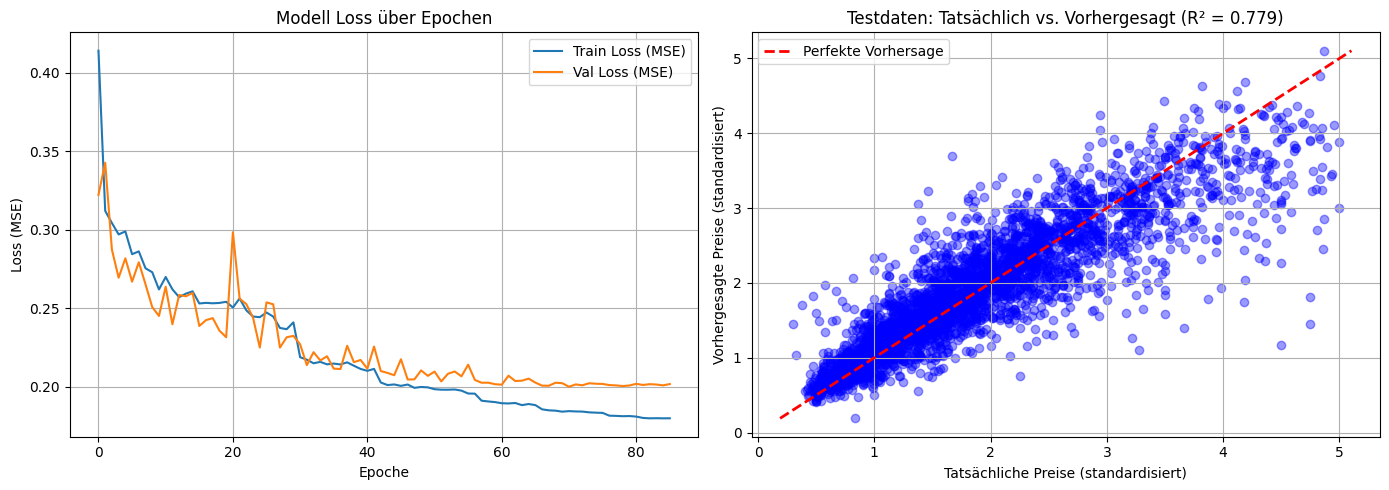


Bestes Modell gespeichert unter: best_keras_tuner_model.h5


In [27]:
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern...")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 # Auf 1 setzen für Epochen-Output
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0) #verbose auf 1 für aktuellen stand
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")

#plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage)
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modell speichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)
print(f"\nBestes Modell gespeichert unter: {model_path}")

Top-Modelle dieses Durchlaufs landen in: gespeicherte_modelle\run_2026-03-20_09-31-13



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2905
Ensemble R² Score: 0.7946


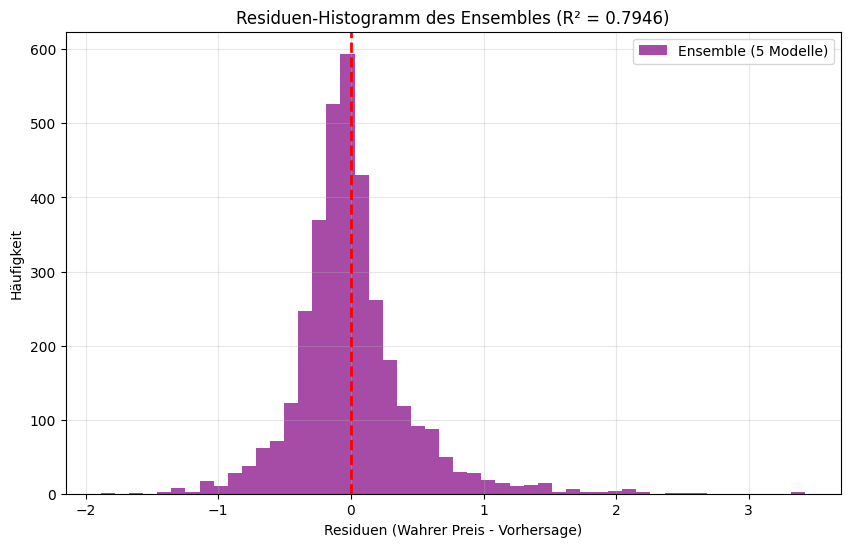

In [28]:
import os
from datetime import datetime


base_model_dir = "gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Top-Modelle dieses Durchlaufs landen in: {current_run_dir}\n")

# vorher trainierte Modelle aufrufen
num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

#ENSEMBLE BILDEN 
# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")

#RESIDUEN PLOTTEN
plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Verändertes Featureengeneerning

Ki Prmopt: "Wie kann ich die Performance des R^2 durch Featureengeneerning auf über 0.8 bringen?"
Idee:  Features vor dem Training des neuronalen Netzes miteinander verrrechnen
 - bereits geschehen bei AveRooms und AveOccup
 - Nun auch mit "AveBedrms"/"AveRooms" = "Bedrooms_per_Room"
   - Tipp von Ki: Population logarithmisch betrachten und Nullfehler vermeiden durch +1
 - restlicher code zunächst unverändert
   - Ergebnis: 0.7922
 - Anpassung der Architektur: geringere Tiefe zur unterbindung des      gradient vanishing und zur Stabilisierunh
 - verringerte Rechenzeit nun nutzen für noch höhere Breite
   - durch Dropout auswendig lernen verhindern
- entfernen der Kommentare zu bereits erklärten Funktionen

#


In [9]:

df = load_and_clean_data()

# geografische Features
# Koordinaten der Zentren (Breitengrad, Längengrad)
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
# Distanz zu San francisco und Los Angeles
df['Dist_to_SF'] = np.sqrt((df['Latitude'] - sf_lat)**2 + (df['Longitude'] - sf_lon)**2)
df['Dist_to_LA'] = np.sqrt((df['Latitude'] - la_lat)**2 + (df['Longitude'] - la_lon)**2)
#Kombinationsfeature
df['Lat_x_Lon'] = df['Latitude'] * df['Longitude']

df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']

# Logarithmus der Bevölkerung 
df['Log_Population'] = np.log(df['Population'] + 1) # +1 um Nullfehler auszuschließen
# ------------------------------------------
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")

X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']


In [ ]:
# redundant, falls zuvor nicht ausgeführt 
import keras_tuner as kt
from sklearn.metrics import r2_score

def build_tuner_model(hp):
    """Definiere das Modell mit Hyperparametern, die vom Keras Tuner optimiert werden sollen."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_standard.shape[1],)))
    
    # 1. Hyperparameter: Aktivierungsfunktion (tanh war gut, elu und relu als Alternativen)
    activation = hp.Choice('activation', values=['tanh', 'relu', 'elu','leaky_relu'])
    
    # 2. Hyperparameter: Anzahl Neuronen Layer 1 
    units_1 = hp.Int('units_1', min_value=32, max_value=512, step=16) #min und max value bestimmen Anzahl der Neuronen/ Layer
    model.add(layers.Dense(units_1, activation=activation)) #<- Breite erhöht
    
    # Optionaler Dropout gegen Overfitting (wird vom Tuner getestet)
    # Dropout: einzelne Neuronen zur Berechnung zufällig ausschließen, um overfitting zu verhindern.
    dropout_1 = hp.Float('dropout_1', min_value=0.0, max_value=0.3, step=0.1) #bis 30% können ausgeschlossen werden. 
    if dropout_1 > 0:
        model.add(layers.Dropout(dropout_1))
    
    # 3. Hyperparameter: Anzahl Neuronen Layer 2 
    units_2 = hp.Int('units_2', min_value=16, max_value=512, step=16) #<- Breite erhöht
    model.add(layers.Dense(units_2, activation=activation))
    
    # 5. Hyperparameter: Anzahl Neuronen Layer 3
    #testweise einführung eines weiteren Layers 
    units_3 = hp.Int('units_3', min_value=16, max_value=256, step=16)
    model.add(layers.Dense(units_3, activation=activation))
    ###herausgenommen um tiefe zu verringern

    # Output Layer
    model.add(layers.Dense(1))
    
    # 4. Hyperparameter: Lernrate (Logarithmische Suche im relevanten Bereich)
    learning_rate = hp.Float('learning_rate', min_value=1e-3, max_value=1e-2, sampling='log')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [ ]:

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     #MSE auf den Validierungsdaten minimieren
    max_trials=30,            # Anzahl der zu testenden Kombinationen
    num_initial_points=5,     
    directory='tuning_dir',
    project_name='california_housing_bayes',
    overwrite=True            
)

print("Starte Hyperparameter-Tuning...")
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,               # Maximal Epochen, meist greift EarlyStopping früher
    batch_size=32,            
    callbacks=[early_stopping, lr_scheduler],
    verbose=1                 #anzeige eines Ladebalkens
)

# Beste Parameter ausgeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")

Trial 14 Complete [00h 01m 44s]
val_loss: 0.19036471843719482

Best val_loss So Far: 0.19036471843719482
Total elapsed time: 00h 15m 05s

Search: Running Trial #15

Value             |Best Value So Far |Hyperparameter
leaky_relu        |elu               |activation
512               |512               |units_1
0.1               |0.2               |dropout_1
416               |496               |units_2
16                |64                |units_3
0.0074911         |0.001             |learning_rate



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Epoch 1/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4124 - mae: 0.4544 - val_loss: 0.2930 - val_mae: 0.3829 - learning_rate: 0.0075
Epoch 2/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3080 - mae: 0.3976 - val_loss: 0.2454 - val_mae: 0.3592 - learning_rate: 0.0075
Epoch 3/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2910 - mae: 0.3863 - val_loss: 0.2463 - val_mae: 0.3549 - learning_rate: 0.0075
Epoch 4/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2695 - mae: 0.3700 - val_loss: 0.2489 - val_mae: 0.3630 - learning_rate: 0.0075
Epoch 5/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2718 - mae: 0.3716 - val_loss: 0.2438 - val_mae: 0.3486 - learning_rate: 0.0075
Epoch 6/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2716 - mae: 0.3713 - val_loss: 0.2958 - val_mae: 0.3975 - learning_rate: 0.0075
Epoch 7/150
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2657 - mae: 0.3656 - val_loss: 0.2498 - val_mae: 0.3564 - learning_rate: 0.0075

### Stärkstes Einzelmodell


Trainiere finales Modell mit den besten Parametern...
Epoch 65: early stopping
Restoring model weights from the end of the best epoch: 50.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.1966
MAE:           0.2992
R² Score:      0.7836


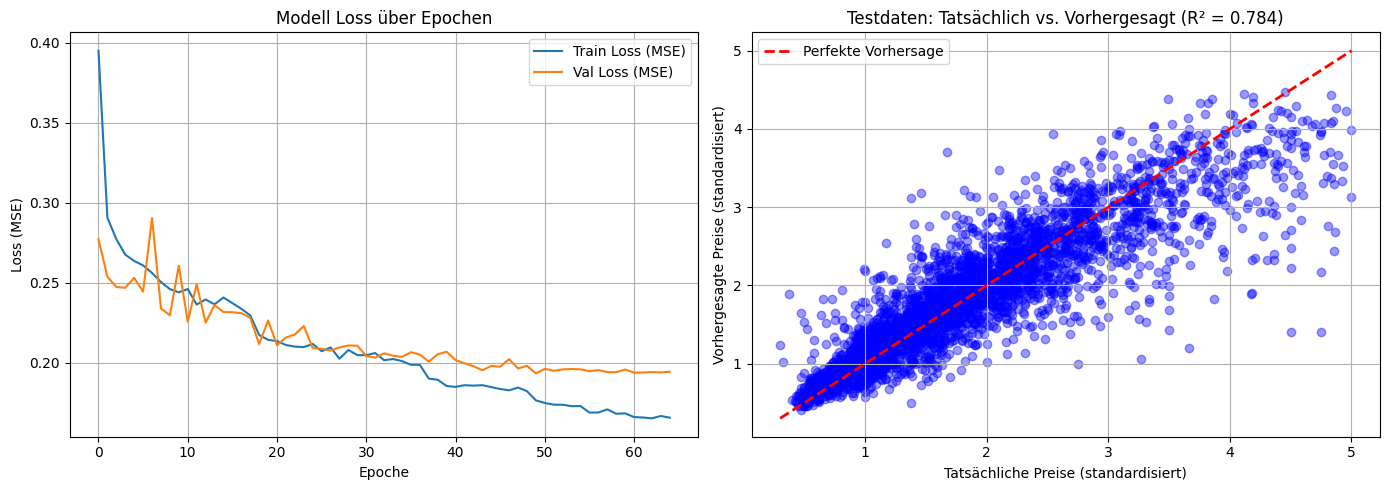


Bestes Modell gespeichert unter: best_keras_tuner_model.h5


In [106]:
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern...")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 # Auf 1 setzen für Epochen-Output
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0)
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage)
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modell abspeichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)
print(f"\nBestes Modell gespeichert unter: {model_path}")

Im linken Plot ist die Abnahme des Loss über die Epochen zu sehen. Es ist zu erkennen, dass weitere Epochen realtiv schnell keiner weiteren Verbesserung der Ergebnisse auf die Validierungsdaten helfen. 
-> mehr Epochen helfen einem besseren Modell nicht weiter
-> kein Problem durch baysiansische Optimierung werden die meisten Durchgänge lang vorher abgebrochen


Top-Modelle dieses Durchlaufs landen in: C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-21_14-23-11



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2924
Ensemble R² Score: 0.7922


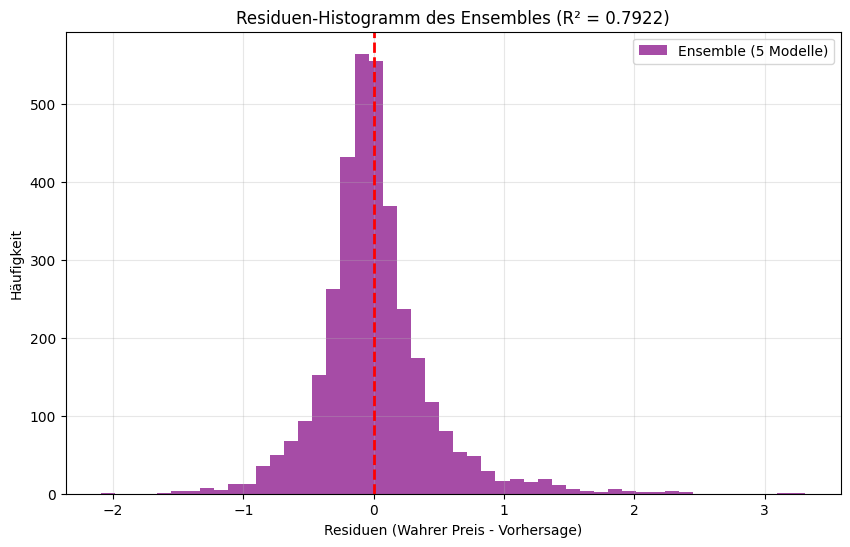

In [ ]:
base_model_dir = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Top-Modelle dieses Durchlaufs landen in: {current_run_dir}\n")

num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")


plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Erneutes laden und ausgeben des R^2-Wertes erfolgt in folgender zelle: 

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


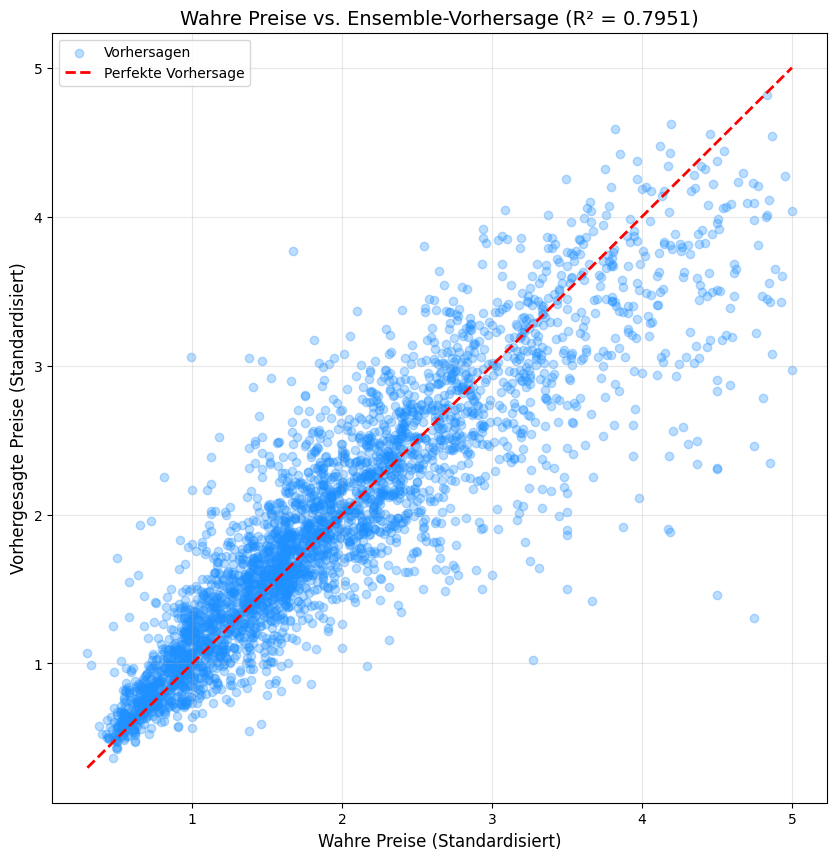

In [117]:
#Laden der Modelle:
#erste zeile mit jeweiligem zeitstempel
modell_ordner = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-20_21-29-14 R^2 = 0.7951"
dateien = ["modell_platz_1.h5", "modell_platz_2.h5", "modell_platz_3.h5", "modell_platz_4.h5", "modell_platz_5.h5"]

all_preds = []

# Jedes Modell einzeln laden und vorhersagen lassen
for datei in dateien:
    pfad = os.path.join(modell_ordner, datei)
    model = tf.keras.models.load_model(pfad, compile=False)
    
    # Vorhersage machen 
    preds = model.predict(X_test_standard).flatten()
    all_preds.append(preds)
    #print(f"{datei} geladen und berechnet.")

# Durchschnitt
y_ensemble_pred = np.mean(all_preds, axis=0)

ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
#print(f"\nEnsemble R² Score: {ensemble_r2:.4f}")

plt.figure(figsize=(10, 10))
# Streudiagramm der Vorhersagen vs Wahre Werte
plt.scatter(y_test_standard, y_ensemble_pred, alpha=0.3, color='dodgerblue', label='Vorhersagen')

# Perfekte Vorhersage-Linie (Diagonale)
min_val = min(np.min(y_test_standard), np.min(y_ensemble_pred))
max_val = max(np.max(y_test_standard), np.max(y_ensemble_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfekte Vorhersage')

plt.title(f'Wahre Preise vs. Ensemble-Vorhersage (R² = {ensemble_r2:.4f})', fontsize=14)
plt.xlabel('Wahre Preise (Standardisiert)', fontsize=12)
plt.ylabel('Vorhergesagte Preise (Standardisiert)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Stand 21.03.2026
- Die bisher stärkste Regression
- Idee:  Obwohl bereits als decisiontree und mit random forst von Björn geschehen, auch einen Random forest einführen. 
- Untersuchung der neu eingeführten Features auf ihren Nutzen für das NN anstatt "blind" Berechnungen zu starten

In [6]:

df = load_and_clean_data()

# geografische Features
# Koordinaten der Zentren (Breitengrad, Längengrad)
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437
# Distanz zu San francisco und Los Angeles
df['Dist_to_SF'] = np.sqrt((df['Latitude'] - sf_lat)**2 + (df['Longitude'] - sf_lon)**2)
df['Dist_to_LA'] = np.sqrt((df['Latitude'] - la_lat)**2 + (df['Longitude'] - la_lon)**2)
#Kombinationsfeature
df['Lat_x_Lon'] = df['Latitude'] * df['Longitude']

df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']

# Logarithmus der Bevölkerung 
df['Log_Population'] = np.log(df['Population'] + 1) # +1 um Nullfehler auszuschließen
# ------------------------------------------
X_train, X_test, y_train, y_test, feature_names = get_train_test_split(df)

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train, y_train = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

X_train_standard, X_test_standard, y_train_standard, y_test_standard,scaler, feature_names = X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

val_split = int(0.8 * len(X_train_standard))
X_val_standard, y_val_standard = X_train_standard[val_split:], y_train_standard[val_split:]
X_train_standard, y_train_standard = X_train_standard[:val_split], y_train_standard[:val_split]

print(f"Training:   {X_train_standard.shape}")
print(f"Validation: {X_val_standard.shape}")
print(f"Test:       {X_test_standard.shape}")
print(f"Features:   {feature_names}")

X_train_min0_max1, X_test_min0_max1, y_train_min0_max1, y_test_min0_max1, scaler, feature_names = get_train_test_split(df, scaler='minmax')

val_split = int(0.8 * len(X_train_min0_max1))
X_val_min0_max1, y_val_min0_max1 = X_train_min0_max1[val_split:], y_train_min0_max1[val_split:]
X_train_min0_max1, y_train_min0_max1 = X_train_min0_max1[:val_split], y_train_min0_max1[:val_split]

print(f"Training:   {X_train_min0_max1.shape}")
print(f"Validation: {X_val_min0_max1.shape}")
print(f"Test:       {X_test_min0_max1.shape}")
print(f"Features:   {feature_names}")



Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']
Training:   (11126, 13)
Validation: (2782, 13)
Test:       (3478, 13)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Dist_to_SF', 'Dist_to_LA', 'Lat_x_Lon', 'Bedrooms_per_Room', 'Log_Population']


Trainiere Random Forest zur Feature-Analyse... (Das kann ein paar Sekunden dauern)


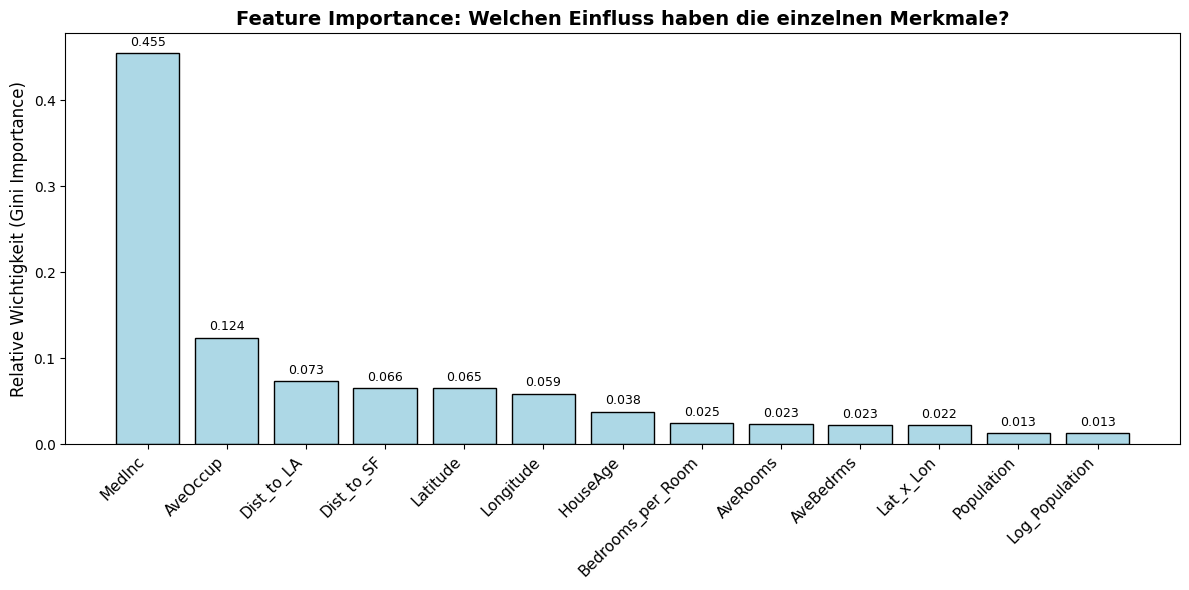

In [ ]:

from sklearn.ensemble import RandomForestRegressor

if isinstance(y_train, pd.DataFrame) or isinstance(y_train, pd.Series):
    y_train_rf = y_train.values.ravel()
else:
    y_train_rf = y_train.ravel()


# n_jobs=-1: alle Kerne desProzessors nutzen
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train_rf)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Absteigend sortieren

#absteigende Reihenfolge
sorted_features = [feature_names[i] for i in indices]
#Plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importance: Welchen Einfluss haben die einzelnen Merkmale?", fontsize=14, fontweight='bold')

# Balkendiagramm 
plt.bar(range(X_train.shape[1]), importances[indices], color='lightblue', edgecolor='black')

# Achsenbeschriftungen anpassen
plt.xticks(range(X_train.shape[1]), sorted_features, rotation=45, ha='right', fontsize=11)
plt.ylabel("Relative Wichtigkeit (Gini Importance)", fontsize=12)

# exakte Werte hinzufügen
for i, val in enumerate(importances[indices]):
    plt.text(i, val + 0.005, f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Training mit optimierten Features

- nun findet das Training des NN, mit bekanntem Code, unter Ausschluss der schwächsten Features zur Beschreibung des Datensatzes statt.


Trial 30 Complete [00h 00m 37s]
val_loss: 0.207310751080513

Best val_loss So Far: 0.19193080067634583
Total elapsed time: 00h 30m 44s

Beste Hyperparameter gefunden:
- Aktivierung: elu
- Layer 1 Neuronen: 208
- Layer 1 Dropout: 0.0
- Layer 2 Neuronen: 464
- Lernrate: 0.00222

Trainiere finales Modell mit den besten Parametern...
Epoch 81: early stopping
Restoring model weights from the end of the best epoch: 66.
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Finale Test-Ergebnisse ---
L2 Loss (MSE): 0.1964
MAE:           0.3002
R² Score:      0.7839


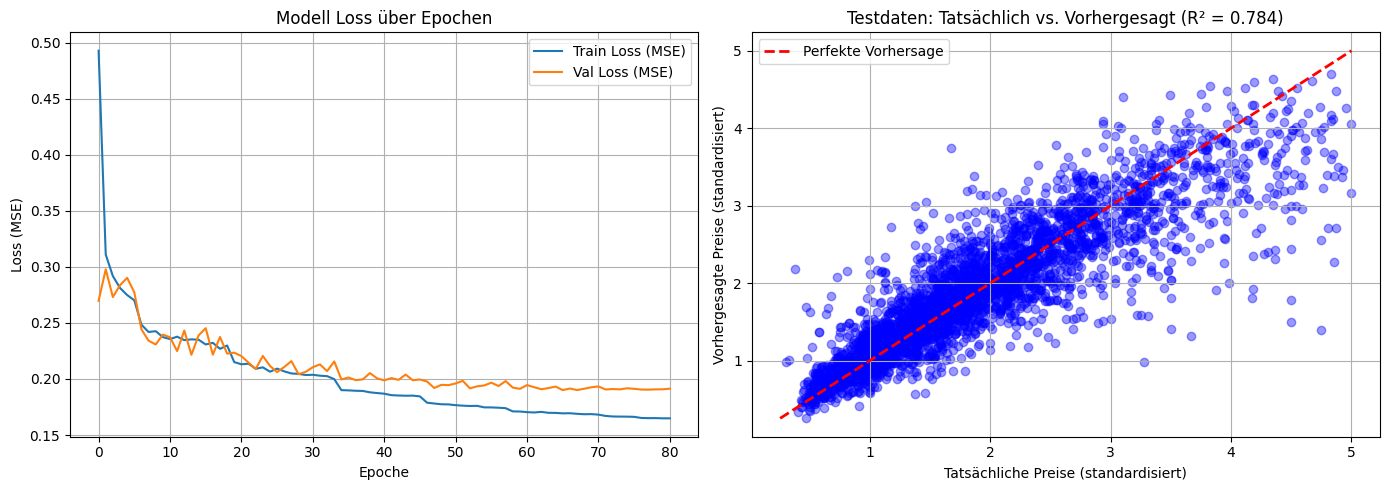

Top-Modelle dieses Durchlaufs landen in: C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle\run_2026-03-22_19-46-03



c:\Users\fneum\.conda\envs\ki1\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> modell_platz_1.h5 erfolgreich gespeichert.


 -> modell_platz_2.h5 erfolgreich gespeichert.


 -> modell_platz_3.h5 erfolgreich gespeichert.


 -> modell_platz_4.h5 erfolgreich gespeichert.
 -> modell_platz_5.h5 erfolgreich gespeichert.

--- Finale Ensemble Test-Ergebnisse ---
Ensemble MAE:      0.2913
Ensemble R² Score: 0.7924


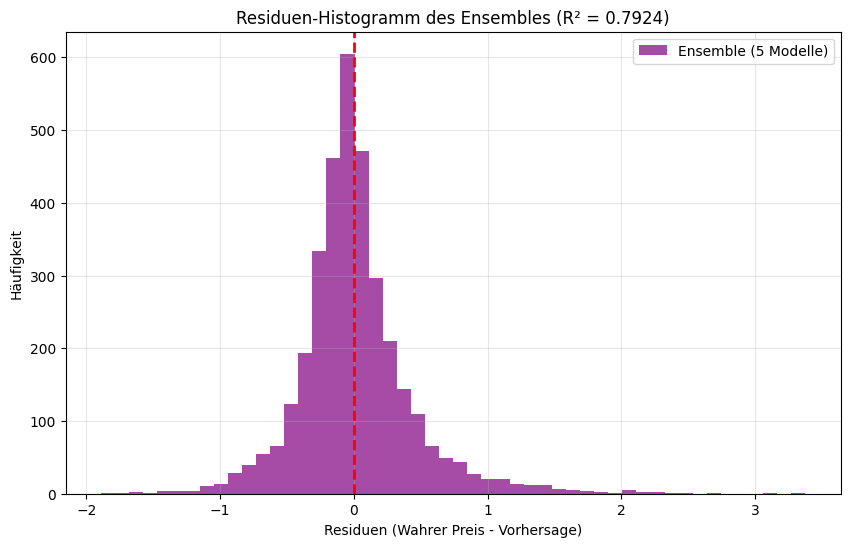

In [127]:
# Ausgeschlossene Features: Population, Log_Population
df.drop(columns=["Population", "Log_Population"])

#ab hier zusammengekürzter bekannter Code
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=0, min_lr=1e-6
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Bayesianischer Tuner
tuner = kt.BayesianOptimization(
    build_tuner_model,
    objective='val_loss',     
    max_trials=30,           
    num_initial_points=5,     
    directory='tuning_dir',
    project_name='california_housing_bayes',
    overwrite=True            
)
tuner.search(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=150,             
    batch_size=32,            
    callbacks=[early_stopping, lr_scheduler],
    verbose=1               
)

# Beste Parameter ausgeben
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBeste Hyperparameter gefunden:")
print(f"- Aktivierung: {best_hps.get('activation')}")
print(f"- Layer 1 Neuronen: {best_hps.get('units_1')}")
print(f"- Layer 1 Dropout: {best_hps.get('dropout_1')}")
print(f"- Layer 2 Neuronen: {best_hps.get('units_2')}")
print(f"- Lernrate: {best_hps.get('learning_rate'):.5f}")
# Bestes Modell mit den optimalen Parametern bauen
best_model = tuner.hypermodel.build(best_hps)

print("\nTrainiere finales Modell mit den besten Parametern...")
history = best_model.fit(
    X_train_standard, y_train_standard,
    validation_data=(X_val_standard, y_val_standard),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=0 
)

# Vorhersagen auf den Testdaten machen
y_test_pred = best_model.predict(X_test_standard).flatten()

mse_test, mae_test = best_model.evaluate(X_test_standard, y_test_standard, verbose=0)
r2_test = r2_score(y_test_standard, y_test_pred)

print(f"\n--- Finale Test-Ergebnisse ---")
print(f"L2 Loss (MSE): {mse_test:.4f}")
print(f"MAE:           {mae_test:.4f}")
print(f"R² Score:      {r2_test:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Trainings- und Validierungsverlauf (L2 Loss / MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Modell Loss über Epochen')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

# Plot Scatterplot Vorhersage vs. Tatsächliche Werte
axes[1].scatter(y_test_standard, y_test_pred, alpha=0.4, color='blue')
# Referenzlinie (Perfekte Vorhersage)
min_val = min(np.min(y_test_standard), np.min(y_test_pred))
max_val = max(np.max(y_test_standard), np.max(y_test_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfekte Vorhersage')

axes[1].set_title(f'Testdaten: Tatsächlich vs. Vorhergesagt (R² = {r2_test:.3f})')
axes[1].set_xlabel('Tatsächliche Preise (standardisiert)')
axes[1].set_ylabel('Vorhergesagte Preise (standardisiert)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modell abspeichern
model_path = "best_keras_tuner_model.h5"
best_model.save(model_path)

base_model_dir = r"C:\Users\fneum\Documents\Uni\Physik\3.Semester\Kuenstliche Intelligenz\Projekt\ki-308\results\gespeicherte_modelle"
os.makedirs(base_model_dir, exist_ok=True)

zeitstempel = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
current_run_dir = os.path.join(base_model_dir, f"run_{zeitstempel}")
os.makedirs(current_run_dir, exist_ok=True)

print(f"Top-Modelle dieses Durchlaufs landen in: {current_run_dir}\n")

num_ensemble_models = 5
top_models = tuner.get_best_models(num_models=num_ensemble_models)

all_preds = []

for i, model in enumerate(top_models):
    # Name und Pfad für die Datei
    m_name = f"modell_platz_{i+1}.h5"
    full_path = os.path.join(current_run_dir, m_name)
    
    # Speichern
    model.save(full_path)
    
    # Vorhersage für das Testset berechnen und sammeln
    preds = model.predict(X_test_standard, verbose=0).flatten()
    all_preds.append(preds)
    print(f" -> {m_name} erfolgreich gespeichert.")

# Durchschnitt aller Vorhersagen bilden
y_ensemble_pred = np.mean(all_preds, axis=0)

# Metriken berechnen
ensemble_r2 = r2_score(y_test_standard, y_ensemble_pred)
ensemble_mae = np.mean(np.abs(y_test_standard - y_ensemble_pred))

print(f"\n--- Finale Ensemble Test-Ergebnisse ---")
print(f"Ensemble MAE:      {ensemble_mae:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")


plt.figure(figsize=(10, 6))
residuen_ensemble = y_test_standard - y_ensemble_pred

plt.hist(residuen_ensemble, bins=50, alpha=0.7, color='purple', label=f'Ensemble ({num_ensemble_models} Modelle)')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuen-Histogramm des Ensembles (R² = {ensemble_r2:.4f})')
plt.xlabel('Residuen (Wahrer Preis - Vorhersage)')
plt.ylabel('Häufigkeit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Ergebnisse Feature drop 
- zunächst ohne "Population" und "Log_Population" 
  - keine Verbesserung bei R^2 und Loss...
Entscheidung:
- da die beiden schwächsten Features noch immer über 1% liefern, beibehalten für das NN. Neuronale Netze können auch aus kleinen Signalen noch Muster schließen, daher hilft es nicht sie zu beschneiden. Dies würde vermutlich erst weit unter einem Prozent zu einem spürbaren Ergebnis führen, da hier das Rauschen dem Informationsgewinn überwiegt.

Dieser Eindruck und auch die sehr geringe Hilfe der neu hinzugefügten Features wird zusätzlich durch die Korrealtionsanalyse unterstützt: 

Gespeichert: results/eda_correlation_heatmap.png und results/eda_correlation_heatmap.pdf


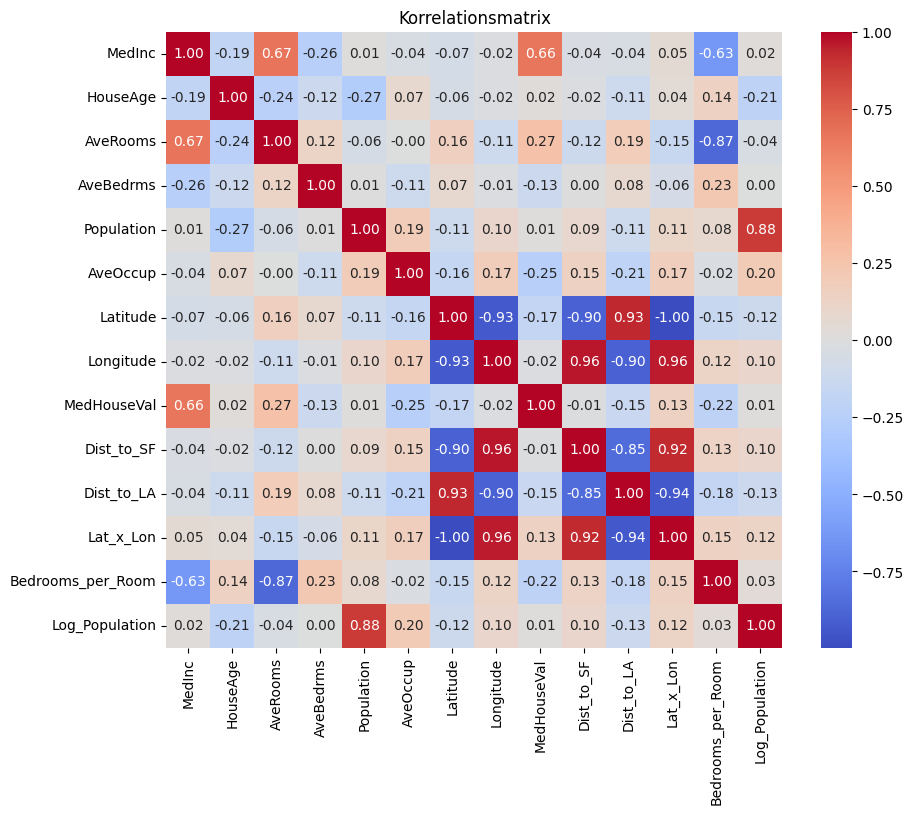

In [8]:
from utils.plotting import plot_correlation_heatmap
fig, ax = plot_correlation_heatmap(df, save_name="eda_correlation_heatmap")
plt.show()

## Zusammenfassung
- Hinzufügen des Features ("AveBdrm") ergab keine Verbesserung
  - allerdings zuvor schon sehr guter Wert und ähnliche Werte konnten erreicht werden
- hinzufügen leaky relu ebenfalls keine deutliche Verbesserung

Stand 22.03.2026